In [1]:
import torchvision.datasets as datasets
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=None)
datatrain=[(xi.reshape(784), yi) for xi, yi in zip(mnist_trainset.data, mnist_trainset.targets)]
datatrain, data_val=train_test_split(datatrain, test_size=1/6)

mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=None)
datatest=[(xi.reshape(784), yi) for xi, yi in zip(mnist_testset.data, mnist_testset.targets)]

loaderTrain=torch.utils.data.DataLoader(datatrain, batch_size=2500, shuffle=True)
loaderVal=torch.utils.data.DataLoader(data_val, batch_size=len(data_val), shuffle=True)
loaderTest=torch.utils.data.DataLoader(datatest, batch_size=len(datatest), shuffle=True)


cpu


Text(0.5, 1.0, 'tensor(4)')

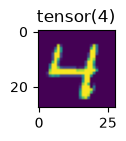

In [2]:
import matplotlib.pyplot as plt
ind=np.random.randint(0, len(mnist_trainset))
x=mnist_trainset.data[ind].numpy()
y=mnist_trainset.targets[ind]
plt.figure(figsize=(1,1))
plt.imshow(x)
plt.title(str(y))

In [3]:
x,y=next(iter(loaderTrain))
print(x.shape, y.shape)

torch.Size([2500, 784]) torch.Size([2500])


In [4]:
# Creación del modelo:
modelo=torch.nn.Sequential(
    torch.nn.Linear(784, 100),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.2),
    torch.nn.Linear(100, 10),
    torch.nn.ReLU()
)

xi, yi=datatrain[0]
xi=xi.unsqueeze(0)
y_est=modelo(xi.float())
print(xi.shape, yi,y_est)

print('-----------------------')

xi, yi=next(iter(loaderTrain))
y_est=modelo(xi.float())
print(xi.shape, yi.shape,y_est.shape)

torch.Size([1, 784]) tensor(7) tensor([[16.6416, 12.4097,  0.0000,  1.4973, 13.1650, 26.4592,  0.0000,  8.3413,
         37.3076, 17.6282]], grad_fn=<ReluBackward0>)
-----------------------
torch.Size([2500, 784]) torch.Size([2500]) torch.Size([2500, 10])


In [5]:
loss=torch.nn.CrossEntropyLoss()
error=loss(y_est, yi)
print(error)
optim=torch.optim.SGD(modelo.parameters(), lr=0.01)

tensor(28.3297, grad_fn=<NllLossBackward0>)


In [6]:
#Proceso de iteración
from tqdm import tqdm
validarCada=10
cntValidacion=0
error=[]
error_validacion=[]
impaciencia=0
PacienciaMaxima=5

epochs=400
for i in tqdm(range(epochs)):
  cntValidacion+=1
  #Entrenamiento
  tmp=[]
  for xi, yi in loaderTrain:
    y_est=modelo(xi.float())
    e=loss(y_est, yi)
    optim.zero_grad()
    e.backward()
    optim.step()
    tmp.append(e.item())
  error.append(np.mean(tmp))
  #Validacion
  if(cntValidacion>=validarCada):
    cntValidacion=0
    for xi, yi in loaderVal:
      with torch.no_grad():
        y_est=modelo(xi.float())
        e=loss(y_est, yi)
        error_validacion.append((i,e.item()))
  if(e.item()>error[-1]): #Conndición incorrecta, estamos en posible sobre entrenamiento
    impaciencia+=1
  else:
    impaciencia=0
    mejor=modelo.state_dict()
  if(impaciencia>=PacienciaMaxima):
    modelo.load_state_dict(mejor)
    print(f'Se sale en la iteración {i} por early stopping')
    break


 18%|█▊        | 70/400 [00:34<02:40,  2.05it/s]

Se sale en la iteración 70 por early stopping


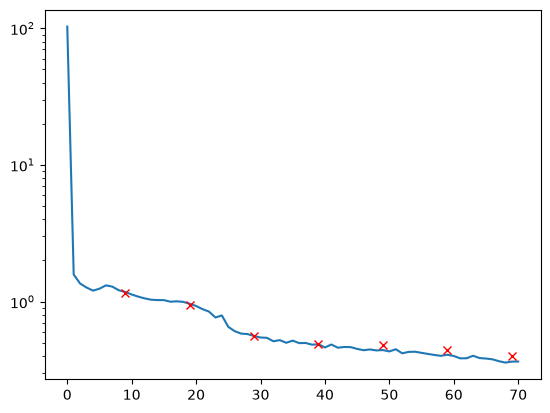

In [7]:
plt.semilogy(error)
ind=[r[0] for r in error_validacion]
val=[r[1] for r in error_validacion]
plt.semilogy(ind, val, 'xr')

In [8]:
#El proceso de validacion
xi, yi=next(iter(loaderTest))
with torch.no_grad():
  y_est=modelo(xi.float())
  print(y_est.shape)
y_est=torch.argmax(y_est, axis=1).numpy()

M=np.zeros((10,10), dtype=int)
for yreal, yest in zip(yi, y_est):
  M[yreal.item(), yest]+=1
M=pd.DataFrame(M, columns=range(10), index=range(10))
import seaborn as sns
sns.heatmap(M, annot=True, fmt="d")
plt.xlabel('Valor estimado')
plt.ylabel('Valor Real')


torch.Size([10000, 10])


ModuleNotFoundError: No module named 'seaborn'

A partir de acá vamos a hacer el modelo con redes convolucionales, pero es el mismo problema de clasificación de dígitos


In [ ]:
#Organizar el Dataset como de imágenes
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=None)
datatrain=[(xi.unsqueeze(0), yi) for xi, yi in zip(mnist_trainset.data, mnist_trainset.targets)]
datatrain, data_val=train_test_split(datatrain, test_size=1/6)

mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=None)
datatest=[(xi.unsqueeze(0), yi) for xi, yi in zip(mnist_testset.data, mnist_testset.targets)]

loaderTrain=torch.utils.data.DataLoader(datatrain, batch_size=2500, shuffle=True)
loaderVal=torch.utils.data.DataLoader(data_val, batch_size=len(data_val), shuffle=True)
loaderTest=torch.utils.data.DataLoader(datatest, batch_size=len(datatest), shuffle=True)

xi,yi=next(iter(loaderTrain))
print(xi.shape, yi.shape)

torch.Size([2500, 1, 28, 28]) torch.Size([2500])


In [ ]:
# Creación del modelo:
modelo=torch.nn.Sequential(
  torch.nn.Conv2d(in_channels=1, out_channels=20, kernel_size=(3,3), stride=1, padding=0),
  torch.nn.MaxPool2d(kernel_size=(2,2), stride=2),
  torch.nn.Conv2d(in_channels=20, out_channels=50, kernel_size=(3,3), stride=1, padding=0),
  torch.nn.MaxPool2d(kernel_size=(2,2), stride=2),
  torch.nn.Conv2d(in_channels=50, out_channels=70, kernel_size=(5,5), stride=1, padding=0),
  torch.nn.Flatten(),
  #Etapa densa multicapa
  torch.nn.Linear(70,30),
  torch.nn.LeakyReLU(),
  torch.nn.Dropout(0.2),
  torch.nn.Linear(30,10),
  torch.nn.LeakyReLU()

)

xi, yi=next(iter(loaderTrain))
y_est=modelo(xi.float())
print(xi.shape, yi.shape,y_est.shape, y_est)

torch.Size([2500, 1, 28, 28]) torch.Size([2500]) torch.Size([2500, 10]) tensor([[ 2.3022e+00, -9.8223e-02,  1.2194e+01,  ...,  1.7810e+00,
         -1.2058e-01,  8.7855e+00],
        [ 4.5519e+00, -2.7145e-02,  3.4232e+00,  ...,  1.3777e+00,
         -3.7061e-02,  3.8439e+00],
        [ 4.1685e+00, -1.1118e-01,  9.1644e+00,  ...,  6.0106e+00,
         -1.8660e-01,  5.3689e+00],
        ...,
        [-3.6452e-03, -6.2375e-02,  7.6192e+00,  ..., -3.8083e-02,
         -9.6802e-02,  4.2122e-01],
        [-4.1334e-02, -2.1670e-02,  3.6664e+00,  ...,  1.0041e-01,
         -3.4802e-02,  2.2653e+00],
        [-2.9225e-02, -4.4397e-02,  8.7341e+00,  ..., -5.9001e-03,
          1.4520e+00, -1.9309e-02]], grad_fn=<LeakyReluBackward0>)


In [ ]:
modelo.to(device)
loss=torch.nn.CrossEntropyLoss()
optim=torch.optim.SGD(modelo.parameters(), lr=0.001)
yi_est=modelo(xi.float().to(device))
e=loss(yi_est, yi.to(device))
print(e)

tensor(8.0766, device='cuda:0', grad_fn=<NllLossBackward0>)


In [ ]:
#Proceso de iteración
from tqdm import tqdm
validarCada=10
cntValidacion=0
error=[]
error_validacion=[]
impaciencia=0
PacienciaMaxima=5

epochs=400
for i in tqdm(range(epochs)):
  cntValidacion+=1
  #Entrenamiento
  tmp=[]
  for xi, yi in loaderTrain:
    y_est=modelo(xi.float().to(device))
    e=loss(y_est, yi.to(device))
    optim.zero_grad()
    e.backward()
    optim.step()
    tmp.append(e.cpu().item())
  error.append(np.mean(tmp))
  #Validacion
  if(cntValidacion>=validarCada):
    cntValidacion=0
    for xi, yi in loaderVal:
      with torch.no_grad():
        y_est=modelo(xi.float().to(device))
        e=loss(y_est, yi.to(device))
        error_validacion.append((i,e.cpu().item()))
  if(e.item()>error[-1]): #Conndición incorrecta, estamos en posible sobre entrenamiento
    impaciencia+=1
  else:
    impaciencia=0
    mejor=modelo.state_dict()
  if(impaciencia>=PacienciaMaxima):
    modelo.load_state_dict(mejor)
    print(f'Se sale en la iteración {i} por early stopping')
    break


 25%|██▌       | 100/400 [01:55<05:46,  1.16s/it]

Se sale en la iteración 100 por early stopping


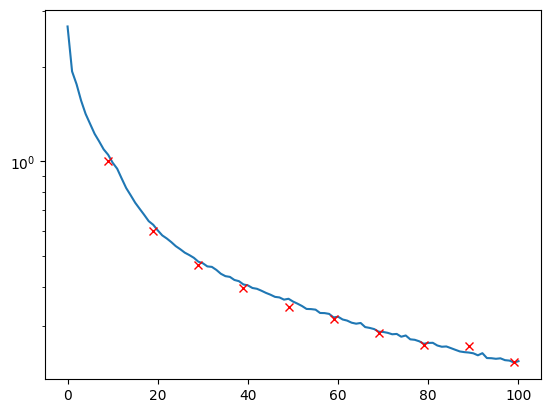

In [ ]:
plt.semilogy(error)
ind=[r[0] for r in error_validacion]
val=[r[1] for r in error_validacion]
plt.semilogy(ind, val, 'xr')

torch.Size([10000, 10])


Text(50.722222222222214, 0.5, 'Valor Real')

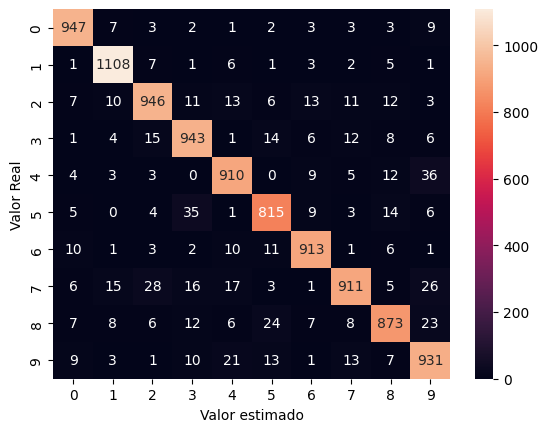

In [ ]:
#El proceso de validacion
xi, yi=next(iter(loaderTest))
with torch.no_grad():
  y_est=modelo(xi.float().to(device))
  print(y_est.shape)
y_est=torch.argmax(y_est, axis=1).cpu().numpy()

M=np.zeros((10,10), dtype=int)
for yreal, yest in zip(yi, y_est):
  M[yreal.item(), yest]+=1
M=pd.DataFrame(M, columns=range(10), index=range(10))
import seaborn as sns
sns.heatmap(M, annot=True, fmt="d")
plt.xlabel('Valor estimado')
plt.ylabel('Valor Real')

(20, 1, 3, 3)


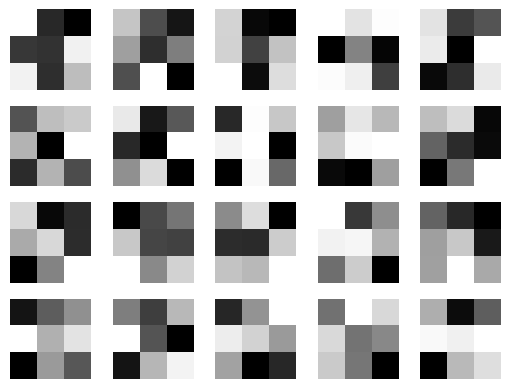

In [ ]:
#miremos los primeros filtros
w=modelo[0].weight.detach().cpu().numpy()
print(w.shape)
plt.figure()
for i in range(20):
  plt.subplot(4,5,i+1)
  plt.imshow(w[i,0], cmap='gray')
  plt.axis('off')


In [ ]:
xi, yi=next(iter(loaderTrain))

torch.Size([1, 28, 28])
(1, 20, 26, 26)


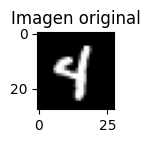

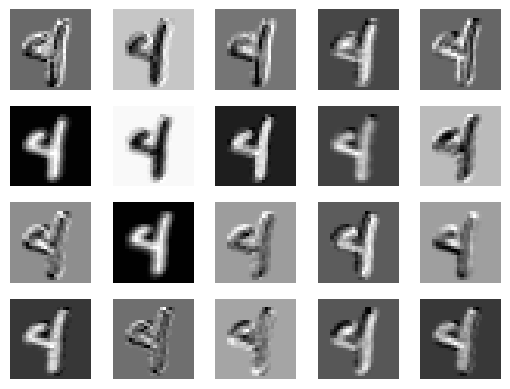

In [ ]:
i=15
x=xi[i]
print(x.shape)
plt.figure(figsize=(1,1))
plt.imshow(x[0].numpy(), cmap='gray')
plt.title('Imagen original')
y=modelo[0](x.unsqueeze(0).float().to(device)).detach().cpu().numpy()
print(y.shape)
plt.figure()
for i in range(20):
  plt.subplot(4,5,i+1)
  plt.imshow(y[0,i], cmap='gray')
  plt.axis('off')